[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/YOUR_GITHUB_USER/YOUR_REPOSITORY/blob/main/YOUR_NOTEBOOK.ipynb)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

sns.set(style="whitegrid")

# ---- load data ----
path = "/content/EFIplus_medit.zip"
df = pd.read_csv(path, compression="zip", sep=";")
df.columns = list(map(str, df.columns))

# ---- filter to four basins ----
basins = ["Douro", "Tejo", "Mondego", "Minho"]
df_sub = df[df["Catchment_name"].isin(basins)].copy()

# ---- quantitative environmental variables (same as earlier) ----
env_vars = [
    "Altitude",
    "Actual_river_slope",
    "Elevation_mean_catch",
    "prec_ann_catch",
    "temp_ann",
    "temp_jan",
    "temp_jul"
]

# drop missing values in any of these
df_env = df_sub[["Catchment_name"] + env_vars].dropna().copy()

# standardize env variables
scaler = StandardScaler()
X = scaler.fit_transform(df_env[env_vars].values)
X_df = pd.DataFrame(X, columns=env_vars, index=df_env.index)

groups = df_env["Catchment_name"]  # factor for colouring

#PCA

In [3]:
pca = PCA(n_components=2)
scores = pca.fit_transform(X_df.values)    # site scores
scores_df = pd.DataFrame(scores, columns=["PC1", "PC2"], index=X_df.index)
scores_df["Catchment_name"] = groups.values

loadings = pca.components_.T              # variable loadings
loadings_df = pd.DataFrame(loadings, index=env_vars, columns=["PC1", "PC2"])

pca.explained_variance_ratio_

array([0.60994399, 0.21480236])

#PCA_BIplot

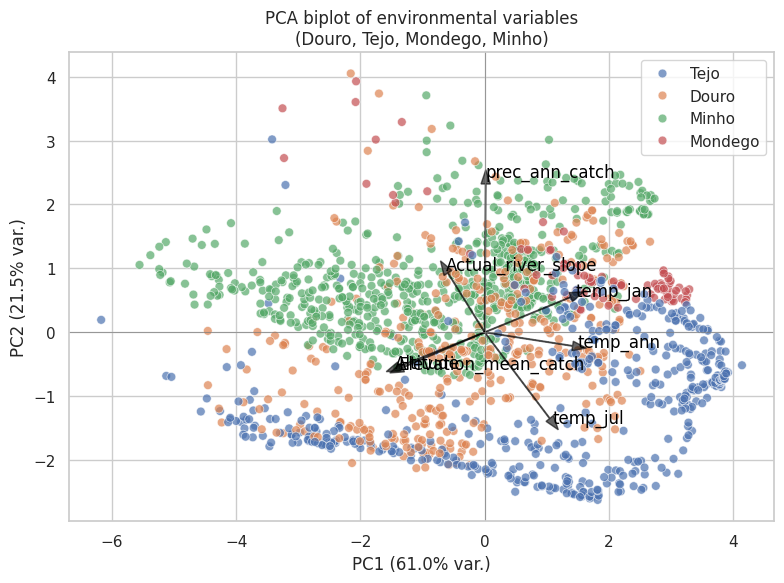

In [4]:
plt.figure(figsize=(8, 6))

# scatter of site scores coloured by basin
sns.scatterplot(
    data=scores_df,
    x="PC1",
    y="PC2",
    hue="Catchment_name",
    alpha=0.7,
    s=40
)

# add loading vectors
for var in env_vars:
    x_loading = loadings_df.loc[var, "PC1"] * 3   # scale factor for visibility
    y_loading = loadings_df.loc[var, "PC2"] * 3
    plt.arrow(0, 0, x_loading, y_loading,
              color="black", alpha=0.6, width=0.01, head_width=0.15)
    plt.text(x_loading*1.05, y_loading*1.05, var, color="black")

pc1_var = pca.explained_variance_ratio_[0]*100
pc2_var = pca.explained_variance_ratio_[1]*100
plt.xlabel(f"PC1 ({pc1_var:.1f}% var.)")
plt.ylabel(f"PC2 ({pc2_var:.1f}% var.)")
plt.title("PCA biplot of environmental variables\n(Douro, Tejo, Mondego, Minho)")
plt.axhline(0, color="grey", linewidth=0.5)
plt.axvline(0, color="grey", linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.show()

#PCoA (Principal Coordinates Analysis) with grouping

In [5]:
from scipy.spatial.distance import pdist, squareform

# Euclidean distances between sites
D = squareform(pdist(X_df.values, metric="euclidean"))

# Classical MDS / PCoA
n = D.shape[0]
J = np.eye(n) - np.ones((n, n))/n
B = -0.5 * J.dot(D**2).dot(J)

eigvals, eigvecs = np.linalg.eigh(B)
idx = np.argsort(eigvals)[::-1]
eigvals = eigvals[idx]
eigvecs = eigvecs[:, idx]

# coordinates (only keep positive eigenvalues)
pos = eigvals > 0
coords = eigvecs[:, pos] * np.sqrt(eigvals[pos])

pcoa_scores = pd.DataFrame(
    coords[:, :2],
    columns=["PCoA1", "PCoA2"],
    index=X_df.index
)
pcoa_scores["Catchment_name"] = groups.values

#Plot PCoA ordination

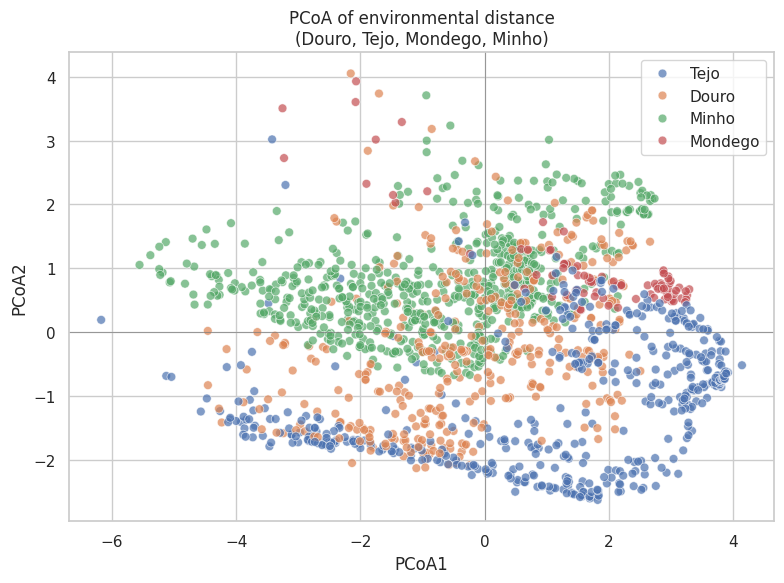

In [6]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=pcoa_scores,
    x="PCoA1",
    y="PCoA2",
    hue="Catchment_name",
    alpha=0.7,
    s=40
)
plt.axhline(0, color="grey", linewidth=0.5)
plt.axvline(0, color="grey", linewidth=0.5)
plt.title("PCoA of environmental distance\n(Douro, Tejo, Mondego, Minho)")
plt.xlabel("PCoA1")
plt.ylabel("PCoA2")
plt.legend()
plt.tight_layout()
plt.show()

##PCoA uses distances directly (not covariance), so it can be used with any distance metric; here Euclidean gives a configuration similar to PCA but is conceptually distance‑based.

#Linear Discriminant Analysis (LDA) and biplot
##Encode groups and fit LDA

In [7]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(groups)   # numeric class labels

lda = LDA(n_components=2)
lda_scores = lda.fit_transform(X_df.values, y)   # site scores in LD space

lda_scores_df = pd.DataFrame(
    lda_scores,
    columns=["LD1", "LD2"],
    index=X_df.index
)
lda_scores_df["Catchment_name"] = groups.values

# coefficients (loadings) for variables on discriminant axes
lda_loadings = lda.scalings_[:, :2]   # shape (n_vars, n_components)
lda_loadings_df = pd.DataFrame(
    lda_loadings,
    index=env_vars,
    columns=["LD1", "LD2"]
)

# LDA biplot

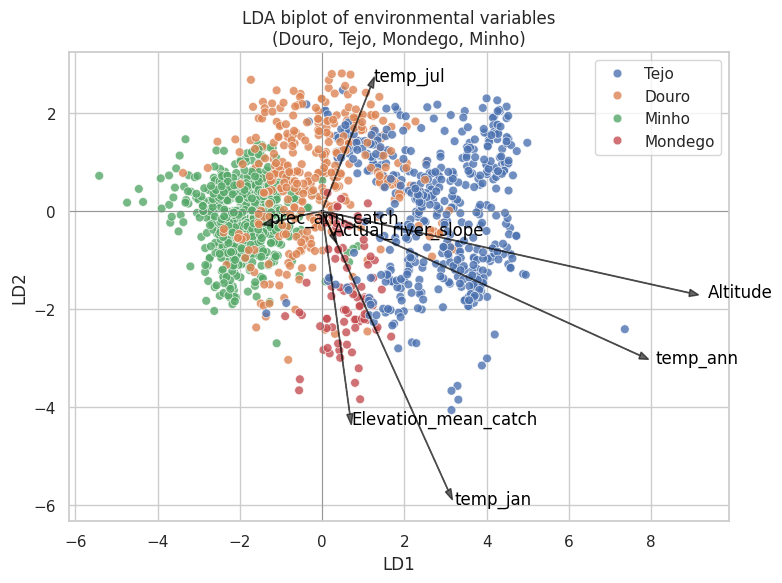

In [8]:
plt.figure(figsize=(8, 6))

# site scores coloured by basin
sns.scatterplot(
    data=lda_scores_df,
    x="LD1",
    y="LD2",
    hue="Catchment_name",
    alpha=0.8,
    s=40
)

# variable vectors (loadings)
for var in env_vars:
    x_l = lda_loadings_df.loc[var, "LD1"] * 2.5
    y_l = lda_loadings_df.loc[var, "LD2"] * 2.5
    plt.arrow(0, 0, x_l, y_l, color="black", alpha=0.6,
              width=0.01, head_width=0.15)
    plt.text(x_l*1.05, y_l*1.05, var, color="black")

plt.axhline(0, color="grey", linewidth=0.5)
plt.axvline(0, color="grey", linewidth=0.5)
plt.xlabel("LD1")
plt.ylabel("LD2")
plt.title("LDA biplot of environmental variables\n(Douro, Tejo, Mondego, Minho)")
plt.legend()
plt.tight_layout()
plt.show()

#LDA explicitly maximizes separation among the four basins, so groups should be more distinct in LD space than in PCA/PCoA.
#The variable vectors show which environmental gradients contribute most to discrimination (e.g. temperature vs altitude vs slope).
#Tejo and Mondego basins are separated mainly along LD1. Minho and Douro and which along LD2. Probaly something to do with the water temp.